In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from split.create_split import create_split
SEED = 42

2026-02-11 11:59:45.664979: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Train LSTM for Sequence Proposing

In [2]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')
df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)

train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-5].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

# One-hot encode and reshape to 3D for LSTM (samples, timesteps, features)
x_one_hot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in x])
print('One-hot encoded shape (3D):', x_one_hot.shape)

X_train, X_val, y_train, y_val = train_test_split(x_one_hot, y, test_size=0.1, random_state=SEED)

print('Training samples: ', X_train.shape[0])
print('Validation samples: ', X_val.shape[0])
print('Input shape (timesteps, features):', X_train.shape[1:])

Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]


I0000 00:00:1770807599.821577   82172 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


One-hot encoded shape (3D): (8670, 8, 4)
Training samples:  7803
Validation samples:  867
Input shape (timesteps, features): (8, 4)


In [14]:
model = Sequential()
model.add(LSTM(100, input_shape = (X_train.shape[1:])))
model.add(Dense(4, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,409 (165.66 KB)

 Trainable params: 42,409 (165.66 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(X_train, y_train, epochs=20, batch_size = 32, validation_data=(X_val, y_val), verbose=1)

Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0235 - mae: 0.1113 - val_loss: 0.0060 - val_mae: 0.0653
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0102 - mae: 0.0782 - val_loss: 0.0054 - val_mae: 0.0617
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0065 - mae: 0.0652 - val_loss: 0.0053 - val_mae: 0.0609
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0056 - mae: 0.0609 - val_loss: 0.0053 - val_mae: 0.0596
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0055 - mae: 0.0603 - val_loss: 0.0051 - val_mae: 0.0593
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0054 - mae: 0.0599 - val_loss: 0.0049 - val_mae: 0.0576
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - mae: 0.0594 - val_loss: 0.0049 - val_mae: 0.0581
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - mae: 0.0592 - val_loss: 0.0049 - val_mae: 0.0584
Epoch 9/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - lo

In [16]:
# save trained model
model.save('lstm_sequence_model.h5')

In [17]:
# evaluate the model
test_loss = model.evaluate(X_val, y_val)
print('Test Loss:', test_loss)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - mae: 0.0571
Test Loss: [0.0047780899330973625, 0.05705997720360756]


### Train LSTM with Reniforcement Learning

In [3]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')
df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)

train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-5].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

# One-hot encode and reshape to 3D for LSTM (samples, timesteps, features)
x_one_hot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in x])
print('One-hot encoded shape (3D):', x_one_hot.shape)

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)

print('Training samples: ', X_train.shape[0])
print('Validation samples: ', X_val.shape[0])
print('Input shape (timesteps, features):', X_train.shape[1:])

Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]
One-hot encoded shape (3D): (8670, 8, 4)
Training samples:  7803
Validation samples:  867
Input shape (timesteps, features): (8,)


In [4]:
from models.random_forest import RandomForestPredictor
rf = RandomForestPredictor()
rf.train(X_train, y_train)

Training Random Forest model...
Training completed.


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [6]:
from models.lstm_goaldirected import LSTMGoalDirected

def train_goal_directed_model(model, loader, epochs=20, lr= 0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            #print('Input shape:', input.shape)
            #print('Target part shape:', batch_y.shape)
            logits, _ = model(input, batch_y)
            loss = criterion(logits.reshape(-1, 4), target_part.reshape(-1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(loader)}')

model = LSTMGoalDirected(vocab_size=4, embedding_dim=16, seq_len=8, hidden_dim=64)

train_goal_directed_model(model, train_loader, epochs=20, lr=0.001)

Epoch 1/20, Loss: 1.3559075232411995
Epoch 6/20, Loss: 1.3162001840403823
Epoch 11/20, Loss: 1.2945604001889464
Epoch 16/20, Loss: 1.2767866688673613


In [7]:
generated_seq = model.generate(1)

print('Generated sequence:', generated_seq, 'Predicted binding score:', rf.predict(generated_seq))


Generated sequence: [0, 2, 3, 0, 3, 0, 0, 0] Predicted binding score: 0.35626502225414314


Step 1: Mutation: [1, 1, 3, 0, 0, 2, 0, 3] not scored by oracle, skipping.
Step 2: Mutation: [0, 2, 0, 2, 3, 0, 1, 0], Predicted Score: 0.34064288436792045
Step 3: Mutation: [0, 0, 3, 2, 2, 3, 2, 2], Predicted Score: 0.34252108768614226
Step 5: Mutation: [2, 1, 3, 1, 3, 0, 1, 0] not scored by oracle, skipping.
Step 6: Mutation: [0, 3, 3, 3, 3, 0, 2, 0], Predicted Score: 0.3728886184083569
Step 9: Mutation: [3, 3, 3, 0, 3, 0, 2, 3] not scored by oracle, skipping.
Step 10: Mutation: [1, 3, 3, 3, 0, 2, 0, 2] not scored by oracle, skipping.
Step 18: Mutation: [0, 3, 3, 0, 0, 3, 3, 3] not scored by oracle, skipping.
Step 20: Mutation: [0, 3, 3, 0, 2, 3, 3, 0] not scored by oracle, skipping.
Step 21: Mutation: [0, 3, 3, 0, 2, 3, 2, 0] not scored by oracle, skipping.
Step 28: Mutation: [1, 2, 3, 0, 0, 0, 2, 0] not scored by oracle, skipping.
Step 29: Mutation: [2, 2, 3, 0, 0, 2, 0, 0] not scored by oracle, skipping.
Step 33: Mutation: [0, 1, 3, 0, 3, 0, 0, 0] not scored by oracle, skipping.
S

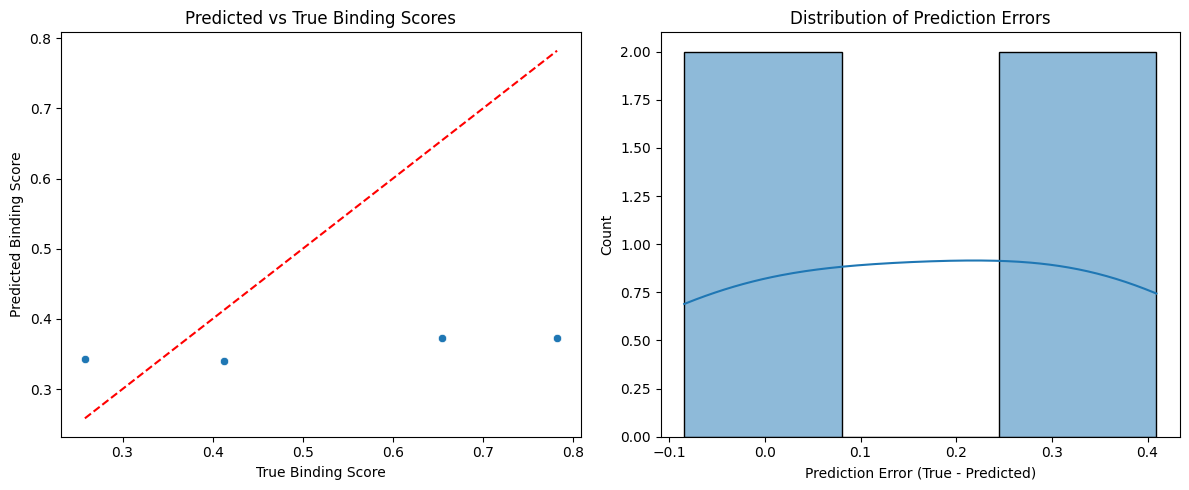

In [27]:
from main_scorer import mutate_score_sequences, check_already_scored, plot_results, lookup_oracle
from models.oracle import build_oracle_df, oracle_exists, oracle_lookup

test_df = df[df['split'] == 'test_c']
oracle = build_oracle_df(test_df)

wanted_score = 0.9
old_score = 0

def mutate_score_sequences(model, scorer, oracle, steps = 100, old_score = 0):
    values = {'mutation': [], 'predicted_score': []}
    for step in range(steps):
        sequence = model.generate(wanted_score)
        one_hot_sequence = tf.one_hot(sequence, depth=4).numpy().flatten()
        if oracle_exists(oracle, one_hot_sequence):
            score = rf.predict(sequence)

            if score > old_score:
                print(f'Step {step+1}: Mutation: {sequence}, Predicted Score: {score}')
                values['mutation'].append(one_hot_sequence)
                values['predicted_score'].append(score)
                old_score = score
            else:
                continue
        else:
            print(f'Step {step+1}: Mutation: {sequence} not scored by oracle, skipping.')
    return values


values = mutate_score_sequences(model, rf, oracle, steps=100, old_score=old_score)
values_df = pd.DataFrame(values)
values_df.head()
values = lookup_oracle(values_df, oracle)
plot_results(values)



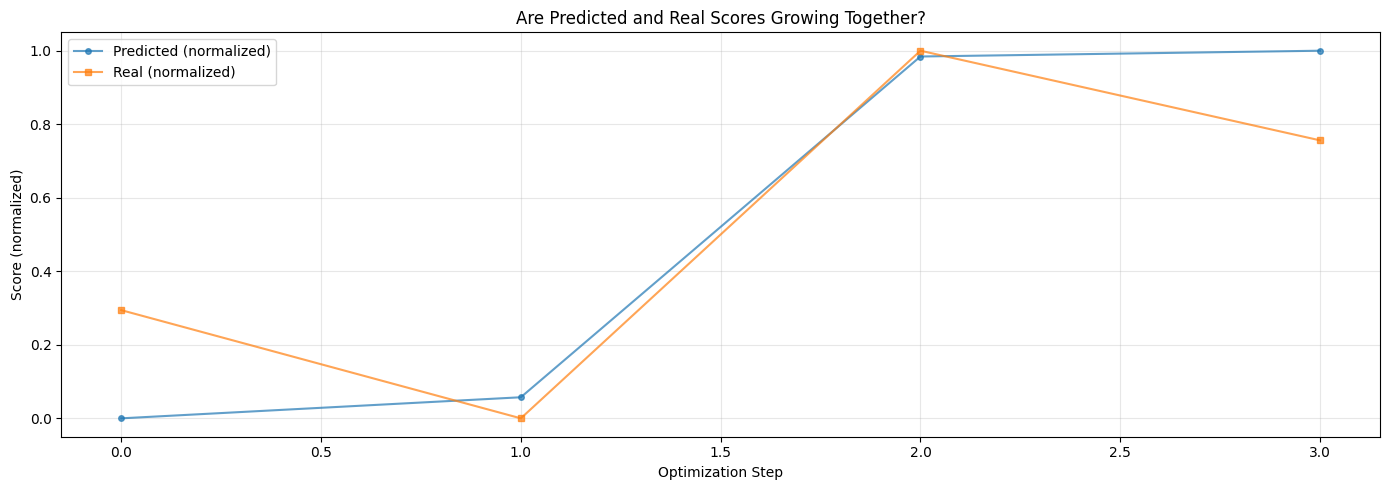

In [29]:
plt.figure(figsize=(14, 5))
df_values = values_df.copy()

# Normalize both to 0-1 range for comparison
pred_norm = (df_values['predicted_score'] - df_values['predicted_score'].min()) / (df_values['predicted_score'].max() - df_values['predicted_score'].min())
real_norm = (df_values['real_score'] - df_values['real_score'].min()) / (df_values['real_score'].max() - df_values['real_score'].min())

plt.plot(pred_norm, label='Predicted (normalized)', marker='o', markersize=4, alpha=0.7)
plt.plot(real_norm, label='Real (normalized)', marker='s', markersize=4, alpha=0.7)
plt.xlabel('Optimization Step')
plt.ylabel('Score (normalized)')
plt.title('Are Predicted and Real Scores Growing Together?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Iterative Feedback Loop with retraining

In [49]:
def rl_loop(model, scorer, num_iterations=5, batch_size = 128):
    values = {'mutation': [], 'predicted_score': []}
    for i in range(num_iterations):
        print(f'-------- Iteration {i+1}/{num_iterations} --------')
        
        new_sequences = []
        # Propose new sequences
        for _ in range(batch_size):
            seq = model.generate(goal_score=1.1, temp = 0.5)
            new_sequences.append(seq)

        new_sequences_np = np.array(new_sequences)
        scores = []

        for seq in new_sequences_np:
            scores.append(scorer.predict(seq))

        scores = np.array(scores)

        normalized_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

        threshold = np.percentile(normalized_scores, 80)

        top_sequences = new_sequences_np[normalized_scores >= threshold]
        top_scores = normalized_scores[normalized_scores >= threshold]

        print(f'Average score of proposed: {np.mean(scores):.4f}, Average score of top 20%: {np.mean(top_scores):.4f}')

        # Append for plotting
        top_sequences_one_hot = [tf.one_hot(seq, depth=4).numpy() for seq in top_sequences]
        values['mutation'].extend(top_sequences_one_hot)
        values['predicted_score'].extend(top_scores)

        # Update model with top sequences
        x_train = torch.LongTensor(top_sequences)
        y_train = torch.FloatTensor(top_scores).view(-1, 1)

        dataloader = DataLoader(TensorDataset(x_train, y_train), batch_size=16, shuffle=True)
        train_goal_directed_model(model, dataloader, epochs=5, lr=0.001)

    return values

model = LSTMGoalDirected(vocab_size=4, embedding_dim=16, seq_len=8, hidden_dim=64)
values = rl_loop(model, rf, num_iterations=5, batch_size=128)
values_df = pd.DataFrame(values)
values_df.head()


-------- Iteration 1/5 --------
Average score of proposed: 0.3303, Average score of top 20%: 0.8405
Epoch 1/5, Loss: 1.3825376629829407
-------- Iteration 2/5 --------
Average score of proposed: 0.3440, Average score of top 20%: 0.9047
Epoch 1/5, Loss: 1.343388557434082
-------- Iteration 3/5 --------
Average score of proposed: 0.3539, Average score of top 20%: 0.9082
Epoch 1/5, Loss: 1.1687215566635132
-------- Iteration 4/5 --------
Average score of proposed: 0.3614, Average score of top 20%: 0.8457
Epoch 1/5, Loss: 0.8241323828697205
-------- Iteration 5/5 --------
Average score of proposed: 0.3670, Average score of top 20%: 0.7700
Epoch 1/5, Loss: 0.5215031305948893


,mutation,predicted_score
0,"[[0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [...",0.811416
1,"[[0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [...",0.848519
2,"[[1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [...",0.850256
3,"[[0.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 0.0], [...",0.770644
4,"[[0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [...",0.901556


In [50]:
# build a oracle with test sets a, b, c 
oracle = build_oracle_df(df[df['split'].isin(['test_a', 'test_b', 'test_c'])])
df_values = lookup_oracle(values_df, oracle)


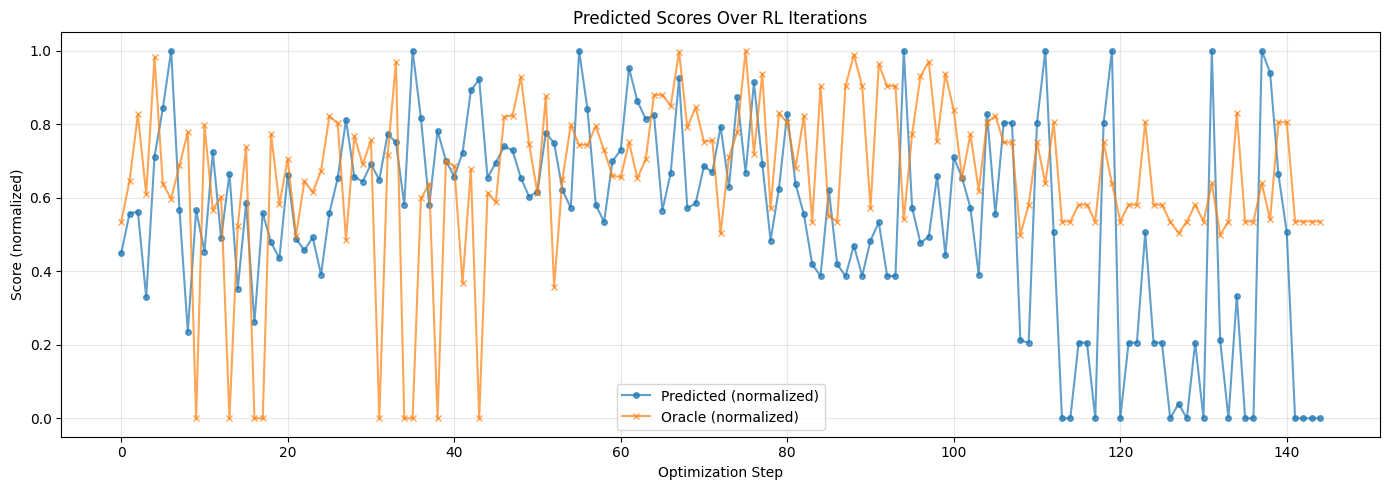

In [52]:
# Plotting the results
plt.figure(figsize=(14, 5))
df_values = values_df.copy()
# Normalize both to 0-1 range for comparison
pred_norm = (df_values['predicted_score'] - df_values['predicted_score'].min()) / (df_values['predicted_score'].max() - df_values['predicted_score'].min())
oracle_norm = (df_values['real_score']  - df_values['real_score'].min()) / (df_values['real_score'].max() - df_values['real_score'].min())

plt.plot(pred_norm, label='Predicted (normalized)', marker='o', markersize=4, alpha=0.7)
plt.plot(oracle_norm, label='Oracle (normalized)', marker='x', markersize=4, alpha=0.7)
plt.xlabel('Optimization Step')
plt.ylabel('Score (normalized)')
plt.title('Predicted Scores Over RL Iterations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()